<a href="https://colab.research.google.com/github/susu-xxx/MyStudy/blob/DeepLearning/ex03_2)_%EA%B0%95%EC%95%84%EC%A7%80_%EA%B3%A0%EC%96%91%EC%9D%B4_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98%EB%B6%84%EB%A5%98_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab Notebooks/SW엔지니어

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


In [3]:
!pwd

/content/drive/MyDrive/Colab Notebooks/SW엔지니어


### 목표
  - MLP , CNN 모델을 활용하여 이미지 분류 실습 진행해보자
  - 이진 분류
  - 성능을 높이기 위한 방법들을 진행해보자
    - 이미지 증식(확장)
    - 전이학습

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# 데이터 불러오기
data = np.load('./data/np_cats_and_dogs.npz')

In [6]:
len(data)

4

In [7]:
x_train = data['x_train']
y_train = data['y_train']
x_test = data['x_test']
y_test = data['y_test']

# 크기 확인
print('훈련세트 : ', x_train.shape, y_train.shape)
print('테스트세트 : ', x_test.shape, y_test.shape)

훈련세트 :  (2000, 224, 224, 3) (2000,)
테스트세트 :  (1000, 224, 224, 3) (1000,)


MLP(다층 퍼셉트론 모델링 수행)
1. 신경망 구조 설계
2. 학습 방법 설정
3. 학습
4. 시각화

In [8]:
# 환경 세팅을 위한 라이브러리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
# 1. 설계
mlp_model = Sequential()

# mlp_model.add(InputLayer(shape=(224,224,3)))
# mlp_model.add(Flatten())

mlp_model.add(Flatten(input_shape=(224,224,3)))

mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(64, activation='relu'))

mlp_model.add(Dense(1, activation='sigmoid'))

# 2. 학습방법 설정
mlp_model.compile(loss='binary_crossentropy',
                  optimizer='adam', # 최적화함수
                  metrics=['accuracy'])

# 조기학습중단
early = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1) # 모델 개선 없을시, 5번까지 반복 후 종료
# 조기학습 중단 연결
mlp_his = mlp_model.fit(
    x_train, y_train,
    validation_split=0.3,
    epochs=20,
    callbacks=[early], # 조기 학습 중단
    verbose=1 # 진행상황 표시
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.5873 - loss: 5681.6006 - val_accuracy: 0.0000e+00 - val_loss: 3292.2158
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6358 - loss: 812.2037 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6007 - loss: 355.7759 - val_accuracy: 0.0267 - val_loss: 592.0833
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6253 - loss: 446.1692 - val_accuracy: 0.9983 - val_loss: 0.5135
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5635 - loss: 681.5457 - val_accuracy: 0.0083 - val_loss: 950.7446
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6421 - loss: 305.0812 - val_accuracy: 0.6650 - val_loss: 76.0290
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6529 - loss: 132.1049 - val_accuracy: 0.4000 - val_loss: 129.8049
Epoch 7: early stopping


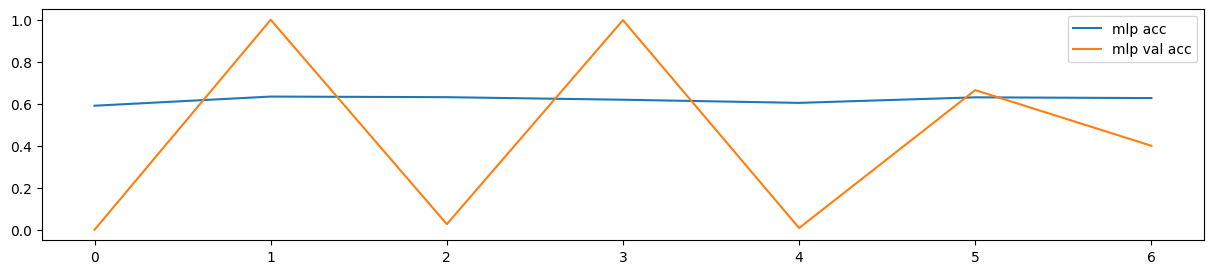

In [10]:
#mlp_his 시각화
plt.figure(figsize = (15,3))

plt.plot(mlp_his.history['accuracy'], label = 'mlp acc')
plt.plot(mlp_his.history['val_accuracy'], label = 'mlp val acc')
plt.legend()
plt.show()

In [11]:
# 모델이 학습자체를 제대로 하지 못한 상황
# 복잡한 데이터, 모델 단순한 송황
# MLP 특성상 이미지에 대한 학습 성능 떨어짐
# 이미지에 대한 파악을 잘 할수 있게 해보자 -> 중요한 특성 추출 학습 _> cnn

#### CNN 모델 생성
1. 모델 설계
  - 뼈대 구축
  특성 추출부 (합성곱)
  분류부
2. 모델 컴파일
3. 학습 및 시각화
4. 예측 및 평가


In [12]:
# 필요한 라이브러리 import
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping
#input Layer 임포트
from tensorflow.keras.layers import InputLayer

#Conv2D : 특징을 잡아내는 역할 (컨볼루셔널 레이어)
# MaxPooling2D : 중요한 부분만 걸러내는 역할(풀링 레이어)

In [13]:
cnn_model = Sequential()

cnn_model.add(InputLayer(input_shape = (224,224,3)))

#------특징 추출부 ----
cnn_model.add(Conv2D(
              filters = 32, #탐지할 눈의 개수
                     kernel_size = (3,3), # 커널의 사이즈, 탐지하는 눈의 크기
                     activation='relu',
                     padding = 'same', #입출력의 크기를 동일하게 하기 위해 가장자리에 0을 채우겠다.
                                      #이미지 자체가 작거나, 가장자리에 중요한 정보가 있는 경우 same: 커널이 밖으로 나갈 경우 0으로 채워짐
                     #이미지 자체가 크겅나 특징이 많을 떄 : valid # 커널이 밖으로 못나감
                     strides = (2,2) #보폭, 커널이 양 옆과 위 아래로 2픽셀씩 이동 // 커널의 보폭
                     ))

cnn_model.add(Conv2D( filters = 32,  kernel_size = (3,3), activation='relu', padding = 'same', strides = (2,2) ))

cnn_model.add(MaxPooling2D(
            pool_size = (2,2)) #풀링 윈도우 지정
            #이미지 탐색에서 그 이미지의 특정 위치의 특징을 요약하는 픽셀 크기 지정




)

#------분류부
cnn_model.add(Flatten()) #차원 축소

cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(64, activation='relu'))

 #출력층
cnn_model.add(Dense(1, activation='sigmoid'))

 #2. 학습방법 설정
cnn_model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# 3. 학습
cnn_his = cnn_model.fit(
    x_train, y_train,
    validation_split=0.3,
    epochs=20,
    batch_size=64,
    callbacks=[early],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.6183 - loss: 25.4536 - val_accuracy: 0.0017 - val_loss: 1.0792
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7465 - loss: 0.5380 - val_accuracy: 0.0367 - val_loss: 1.9103
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8422 - loss: 0.3562 - val_accuracy: 0.1817 - val_loss: 1.8841
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9136 - loss: 0.2237 - val_accuracy: 0.2850 - val_loss: 2.6767
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9429 - loss: 0.1786 - val_accuracy: 0.2017 - val_loss: 3.7577
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9582 - loss: 0.1659 - val_accuracy: 0.3350 - val_loss: 3.7025
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9629 - loss: 0.1124 - val_accuracy: 0.2600 - val_loss: 5.2452
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9819 - loss: 0.0596 - val_accuracy: 0.3033 

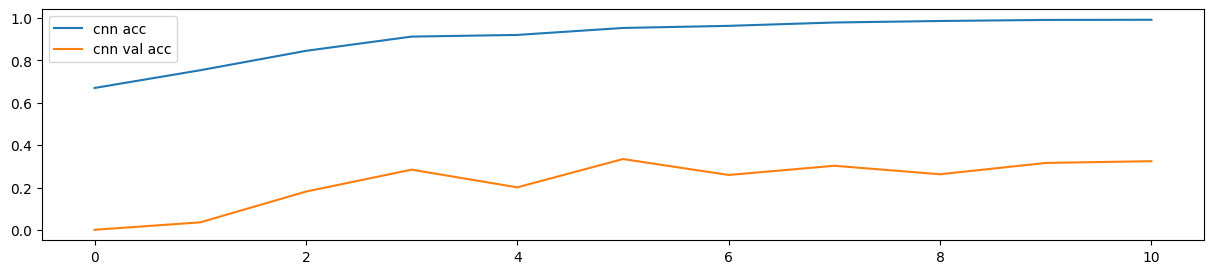

In [14]:
#시각화
plt.figure(figsize = (15,3))

plt.plot(cnn_his.history['accuracy'], label = 'cnn acc')
plt.plot(cnn_his.history['val_accuracy'], label = 'cnn val acc')
plt.legend()


In [15]:
# 성능의 일반화가 mlp보다는 더 된 건 사실이지만
#train에 대해 너무 맞춰서 학습하는 과대적합 현상이 심화됨
#과대적합을 해소하명ㄴ서 모델의 일반화 선응을 더 높여야 함

#### 덷이터 이미지 증강을 통한 CNN 모델 성능 개선
- 데이터 증강,: 이미지 회전, 이동, 확대, 축소 등을 통해 데이터를 늘리는 작업
- 과대적합이 일어나는 이유 중 하나는 훈련 데이터가 부족
- 훈련 데이터가 충분히 많다면, 과대적합을 줄일 수 있음
- 데이터 확장이란 훈련데이터를 다양하게 변형하여 변형된 새로운 훈련데이터를 사용함으로서 마치 훈련 데이터 수가 늘어난 효과를 얻는 것

# 주의사항
- 증강은 훈련데이터에서만 진행


In [16]:
#이미지 크기 조절, 픽셀값 변경, 라벨링, 이미지 데이트 증강 라이브러리
from tensorflow.keras.preprocessing.image import ImageDataGenerator

| 옵션               | 설명                                                       |
|--------------------|------------------------------------------------------------|
| `rescale`          | 입력 이미지의 픽셀 값 재조정(ex.rescale=1.255 -> 모든 픽셀값들에 대해 0~1 사이로 정규화)|
| `rotation_range`   | 이미지의 회전 범위를 설정(ex.rotation_range -> -20~20도 사이에서 무작위로 회전)|
| `width_shift_range`| 이미지의 수평 이동 범위를 설정(ex.0.1은 전체 너비의 10%만큼 좌우로 무작위로 이동) |
| `height_shift_range`| 이미지의 수직 이동 범위를 설정(ex.0.1은 전체 너비의 10%만큼 위아래로 무작위로 이동)|
| `shear_range`      | 시계 반대 방향으로 지정된 각도만큼 변형       |
| `zoom_range`       | 이미지의 확대 및 축소 범위를 설정(ex.0.1 -> 0.9배~1.1배 사이에서 무작위로 확대하거나 축소) |
| `horizontal_flip`  | 이미지를 수평 방향으로 뒤집을지 여부를 설정       |
| `fill_mode`        | 이미지를 변형할 때 생기는 빈 공간을 채우는 방식을 설정(ex.nearest -> 가장 가까운 픽셀값을 사용하여 빈공간 채우기) |


In [17]:
# 증강할 데이터 경로 설정
train_dir = './data/cats_and_dogs_filtered/train'
test_dir = './data/cats_and_dogs_filtered/test'

#증강기 생성 (변형할 형식 지정)
train_gen = ImageDataGenerator(
            rescale =1./255, # 픽셀 하나당 0-255= 0과 1사이의 값으로 만듦= 정규화 = 컴퓨터 학습시 정규화시키면 성능 좋아지니까
            zoom_range = 0.2, # 0.8배 확대 축소 및 확대
            horizontal_flip = True #좌우 반전
            )

test_gen = ImageDataGenerator(rescale=1./255)

In [18]:
#이미지 데이터 제너레이터 생성
#
#지정된 디렉토리에서 이미지를 불러오고 실시간으로 데이터를 생성하는 기능

train_generator = train_gen.flow_from_directory(
    train_dir, #이미지가 저장된 디렉토리 경로
    target_size=(224,224),#이미지 크기
    batch_size=32, #한번에 변환될 이미지의 개수
    class_mode='binary'#이진분류 , #categorical 다중분류
)

test_generator = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


#### DropOut
- 과대적합 개선
- 학습하는 동안에만 적용
- 신경망을 비율에 따라 일부러 활성화되지 않도록 꺼버림

In [19]:
#Dropout 임포트
from tensorflow.keras.layers import Dropout

In [20]:
# 1. 설계--선생님 코드
cnn_model2 = Sequential()

cnn_model2.add(InputLayer(shape=(224,224,3)))

# ---------- 특징 추출부 --------
cnn_model2.add(Conv2D(
    filters = 32,
    kernel_size = (3,3),
    activation = 'relu',
    padding = 'same',
    strides = (2,2)

))

cnn_model2.add(MaxPooling2D(
    pool_size = (2,2) # 풀링 윈도우 지정
    # 이미지 탐색에서 그 이미지의 특정 위치의 특징을 요약하는 픽셀 크기 지정
))

#########
cnn_model2.add(Dropout(0.3))
# pool층에 의해 나온 특징지도(피쳐맵) 중 30% 무작위로 0으로 만든 후 두번째 층으로 넘김
# 예측을 수행할 때는 비활성화

cnn_model2.add(Conv2D(filters = 64, kernel_size = (3,3),   activation = 'relu',padding = 'same',strides = (2,2)  ))
cnn_model2.add(MaxPooling2D(pool_size = (2,2)))

cnn_model2.add(Conv2D(filters = 32, kernel_size = (3,3),   activation = 'relu',padding = 'same',strides = (2,2)  ))
cnn_model2.add(MaxPooling2D(pool_size = (2,2)))

#########
cnn_model2.add(Dropout(0.3))

#--------------분류부----------
cnn_model2.add(Flatten()) # 차원 축소

cnn_model2.add(Dense(256, activation='relu'))

#########
cnn_model2.add(Dropout(0.3))

cnn_model2.add(Dense(128, activation='relu'))
cnn_model2.add(Dense(64, activation='relu'))

# 출력층
cnn_model2.add(Dense(1, activation='sigmoid'))

# 2. 학습방법 설정
cnn_model2.compile(loss='binary_crossentropy',
                  optimizer='adam', # 최적화함수
                  metrics=['accuracy'])

# 3. 학습
cnn_his2 = cnn_model2.fit(
    ## X_train, y_train,
    train_generator, # 이미지 증강 적용

    ## validation_split=0.3,
    validation_data = test_generator,
    # split으로 할 경우, 증강이 적용되기 때문에, 별도의 검증용 데이터셋으로 진행하기를 권장(지금은 test데이터를 사용)

    epochs=20,
    batch_size = 64,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 608s 10s/step - accuracy: 0.4758 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.6915
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 530ms/step - accuracy: 0.5313 - loss: 0.6905 - val_accuracy: 0.5000 - val_loss: 0.6890
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 525ms/step - accuracy: 0.5362 - loss: 0.6887 - val_accuracy: 0.6330 - val_loss: 0.6502
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 541ms/step - accuracy: 0.6072 - loss: 0.6562 - val_accuracy: 0.6140 - val_loss: 0.6449
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 532ms/step - accuracy: 0.6114 - loss: 0.6444 - val_accuracy: 0.6400 - val_loss: 0.6362
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 535ms/step - accuracy: 0.6080 - loss: 0.6482 - val_accuracy: 0.6810 - val_loss: 0.5813
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 519ms/step - accuracy: 0.6454 - loss: 0.6298 - val_accuracy: 0.6490 - val_loss: 0.5994
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 537ms/step - accuracy: 0.6979 - loss: 0.5932 - val_accur

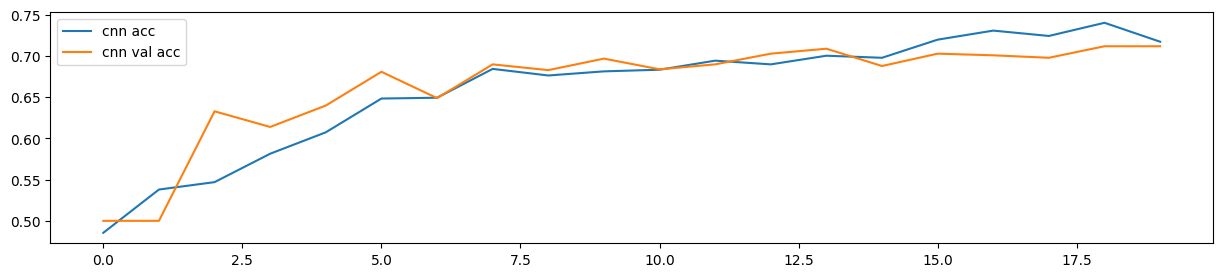

In [21]:
#cnn_his 시각화
plt.figure(figsize = (15,3))

plt.plot(cnn_his2.history['accuracy'], label = 'cnn acc')
plt.plot(cnn_his2.history['val_accuracy'], label = 'cnn val acc')
plt.legend()
plt.show()
순미ㅏㅓㅇㄻㄴㅇ람ㄴㅇㄹㅇㄴ

- 다른 사람이 만든 모델을 사용해보자

In [22]:
from tensorflow.keras.applications import VGG16
# 1000개 다중분류

In [23]:
vgg16 = VGG16(include_top = False,
              weights = 'imagenet',
              input_shape = (224,224,3))
# top : 다중분류기술 , vgg16 모델은 다중분류이므로 사용하지 않는다. 분류층 따로 진행할 예정
#Weights : imagnet -> 기존 학습한 가중치 불러옴


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
#모든 conv층 동결, 가중치 갱신 막아야 함 -> 학습 불가능하게 설정
#vgg16은 100만장 이상의 사진으로 학습이 되어있음. 성능이 좋음

#특성 추출부 고정
for layer in vgg16.layers :
  layer.trainable = False

In [25]:
transfer_model = Sequential()
transfer_model.add(vgg16)

# 분류기층 -> mlp 이중분류 :  개 vs 고양이
transfer_model.add(Flatten())

transfer_model.add(Dense(64, activation='relu'))

transfer_model.add(Dense(1, activation='sigmoid'))

In [26]:
# 학습/평가방법 설정
transfer_model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [27]:
transfer_model_history = transfer_model.fit(
    train_generator,
    validation_data = test_generator,
    epochs=10,
    batch_size = 64,
    verbose=1
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 752ms/step - accuracy: 0.6748 - loss: 0.8444 - val_accuracy: 0.8940 - val_loss: 0.2542
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 575ms/step - accuracy: 0.9090 - loss: 0.2394 - val_accuracy: 0.8780 - val_loss: 0.2631
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 575ms/step - accuracy: 0.9232 - loss: 0.1907 - val_accuracy: 0.9140 - val_loss: 0.1965
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 573ms/step - accuracy: 0.9339 - loss: 0.1666 - val_accuracy: 0.9040 - val_loss: 0.2259
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 570ms/step - accuracy: 0.9429 - loss: 0.1470 - val_accuracy: 0.9080 - val_loss: 0.2140
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 579ms/step - accuracy: 0.9483 - loss: 0.1383 - val_accuracy: 0.9070 - val_loss: 0.2336
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 593ms/step - accuracy: 0.9650 - loss: 0.0929 - val_accuracy: 0.9000 - val_loss: 0.2316
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 585ms/step - accuracy: 0.9674 - loss: 0.0850 - val_accu

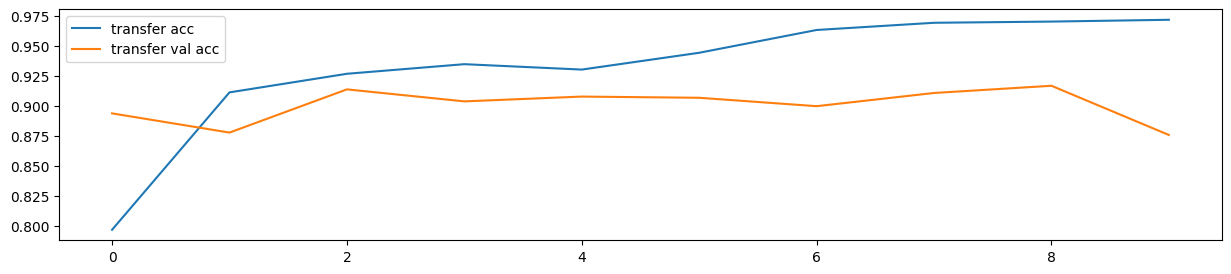

In [28]:
#cnn_his 시각화
#vgg16 모델 전이학습 시각화
plt.figure(figsize = (15,3))

plt.plot(transfer_model_history.history['accuracy'], label = 'transfer acc')
plt.plot(transfer_model_history.history['val_accuracy'], label = 'transfer val acc')
plt.legend()
plt.show()